# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

# Justifying trial type > instatanous state > instatanous speed

## Set up for 14 conditions and 6 areas 

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [3]:
# Load selected group_id
import pickle
with open('group_id_selected_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_selected_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Use self trained K-means results, which have a better likelihood
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [5]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

mean_num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id']==0)]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons in cross-pop in average. ")
    mean_num_neuron.append(np.mean(num_cross_pop))

probeA has 12.225 neurons in cross-pop in average. 
probeB has 14.95 neurons in cross-pop in average. 
probeC has 16.9 neurons in cross-pop in average. 
probeD has 10.625 neurons in cross-pop in average. 
probeE has 7.375 neurons in cross-pop in average. 
probeF has 8.225 neurons in cross-pop in average. 


In [6]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id'].isin([0,1,2]))]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons. ")
    num_neuron.append(np.mean(num_cross_pop))

probeA has 64.0 neurons. 
probeB has 60.0 neurons. 
probeC has 85.0 neurons. 
probeD has 53.0 neurons. 
probeE has 53.0 neurons. 
probeF has 37.0 neurons. 


In [7]:
# Load LFP data
start_time = 0.0
end_time = 0.5
padding = 0.5
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [8]:
# Just to get a wider range of speed
start_time = -0.5
end_time = 1.0
padding = 0
V1_wider = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

V1_wider.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


## No speed

BIC improvement of the model is: 0.0


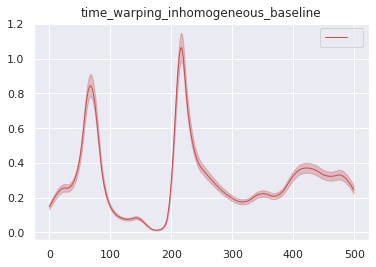

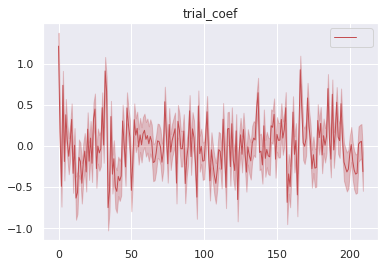

In [47]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 20
num_varying_linear = 20
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
penalty = 5e-1

coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
penalty = 5e-1

select_trials = np.full(V1.ntrial, True)
# select_trials = V1.running_trial_index

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)

baseline_bic = model.bic
print(f"BIC improvement of the model is: {(baseline_bic - model.bic)}")
GLM.plot_GLM_compare(model)

## Simple linear term of speed

BIC improvement of the model is: 75.09250375817646


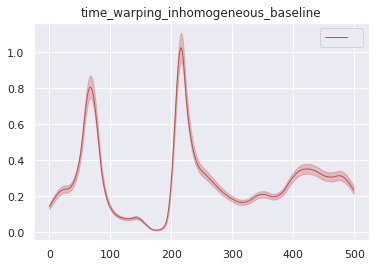

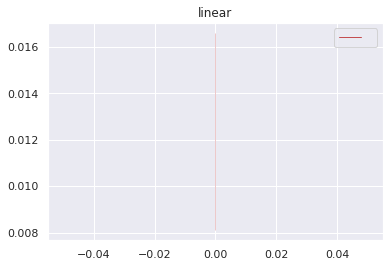

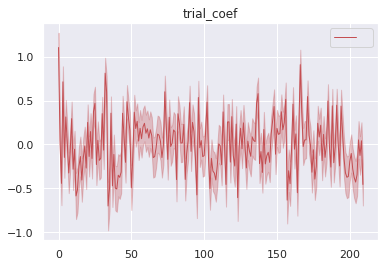

In [52]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 20
num_varying_linear = 20
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
penalty = 5e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('linear', smo, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"BIC improvement of the model is: {(baseline_bic - model.bic)}")
GLM.plot_GLM_compare(model)

## Simple binary term of state

BIC improvement of the model is: 6.927457316589425


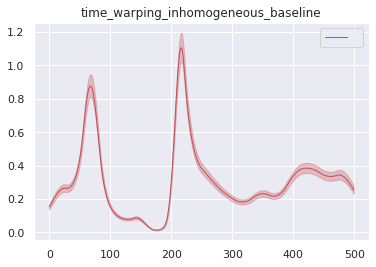

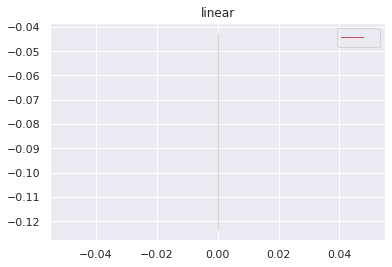

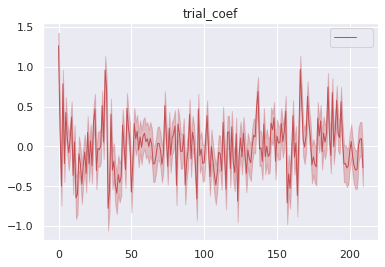

In [53]:
best_time_diff = 100
smooth_std = 20
threshold = 1
num_basis_baseline = 20
num_varying_linear = 20
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
penalty = 5e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('linear', instantaneous_state, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"BIC improvement of the model is: {(baseline_bic - model.bic)}")
GLM.plot_GLM_compare(model)

## Time-varying linear term of speed

BIC improvement of the model is: 555.6866244379344


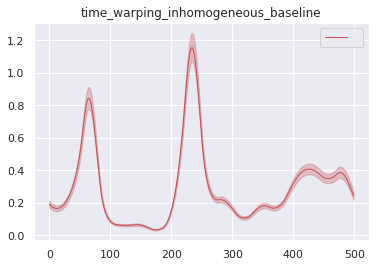

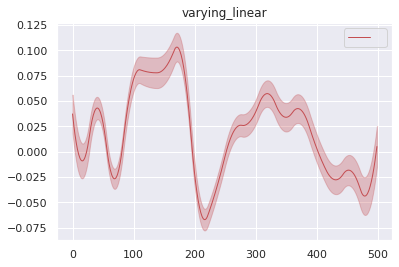

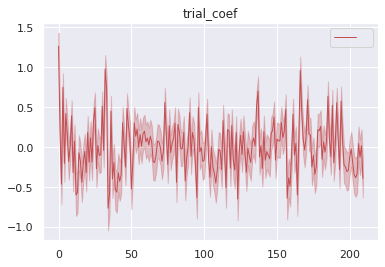

In [54]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 20
num_varying_linear = 20
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
penalty = 5e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"BIC improvement of the model is: {(baseline_bic - model.bic)}")
GLM.plot_GLM_compare(model)

## Time-varying instantaneous binary term of state

BIC improvement of the model is: 914.4255616932642


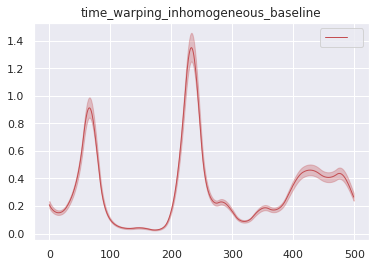

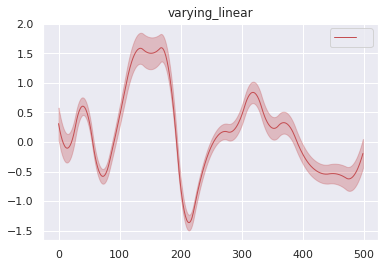

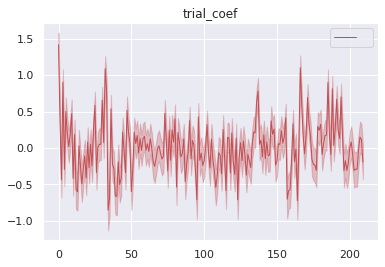

In [55]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 20
num_varying_linear = 20
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
penalty = 5e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('varying_linear', instantaneous_state, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"BIC improvement of the model is: {(baseline_bic - model.bic)}")
GLM.plot_GLM_compare(model)

## Time-varying Trial-wise binary term of state

BIC improvement of the model is: 1454.9887442553882


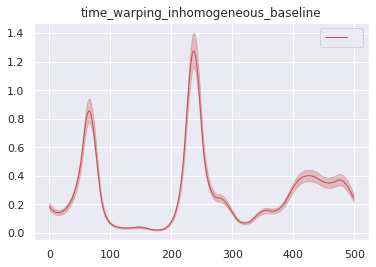

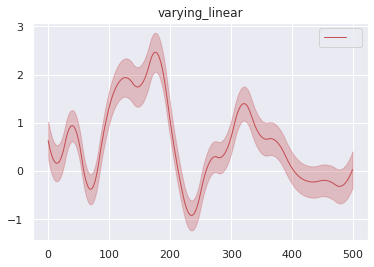

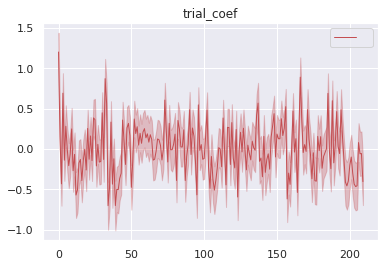

In [56]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 20
num_varying_linear = 20
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
penalty = 5e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)

trial_state = np.zeros_like(V1.speed)
for i in range(trial_state.shape[1]):
    if V1.running_trial_index[i]:
        trial_state[:,i] = 1.0

model.add_effect('varying_linear', trial_state, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"BIC improvement of the model is: {(baseline_bic - model.bic)}")
GLM.plot_GLM_compare(model)

In [33]:
### 90% of the elements are the same in tria-wise state and instantaneous state
np.sum(trial_state == instantaneous_state)/(trial_state.shape[0]*trial_state.shape[1])

0.8979333333333334

## Two-way couping

BIC improvement of the model is: 109.1257383422344


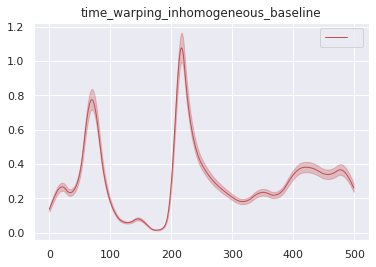

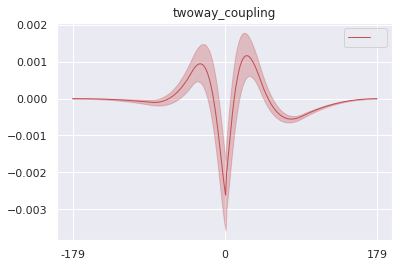

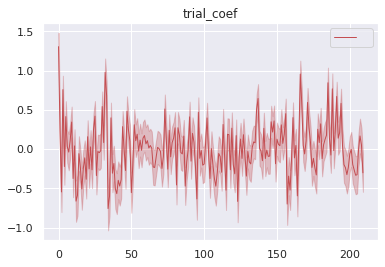

In [57]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 20
num_varying_linear = 20
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
penalty = 5e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('twoway_coupling', smo, peaks_max=40, num=3, nonlinear=0.4, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"BIC improvement of the model is: {(baseline_bic - model.bic)}")
GLM.plot_GLM_compare(model)

# Justify coupling effects should contain history effects with 1st/2nd order interaction terms or just 2nd order term of Lambda

## Baseline (no coupling)

In [35]:
# The following hyperparameters turned out to be the best

target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# for j, input_probe in enumerate(probe_list):
#     model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# for j, input_probe in enumerate(probe_list):
#     model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

baseline_bic = model_running.bic + model_stationary.bic
print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 0.0


## Only cross-area coupling

In [36]:
# The following hyperparameters turned out to be the best

target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 4362.168647511571


## Both cross-area coupling and history

This is unstable when doing simulation

In [37]:
# The following hyperparameters turned out to be the best

target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 5941.715305343678


## With interaction in history effect

In [38]:
# The following hyperparameters turned out to be the best

target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 8183.604322513245


## With only 2nd interaction in history effect

In [39]:
# The following hyperparameters turned out to be the best

target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 7682.5652057890475


## With both 1st and 2nd interaction in history effect

In [40]:
# The following hyperparameters turned out to be the best

target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1
########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 8585.821016394839


## With $\Lambda$ in history effect

In [41]:
# The following hyperparameters turned out to be the best

target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 6383.479589048278


## With $\Lambda^2$ refractory in history effect

In [42]:
# The following hyperparameters turned out to be the best

target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 8094.837088821667


## Interaction in all coupling effects

Not so good

In [43]:
# The following hyperparameters turned out to be the best

target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('interaction', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params,apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('interaction', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params,apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 7182.432589301541


## refractory nonparametric

In [44]:
# The following hyperparameters turned out to be the best

num_f_refractory = 4
target_probe = 'probeC'
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"BIC improvement of the model is: {(baseline_bic - model_running.bic - model_stationary.bic)}")

BIC improvement of the model is: 8929.0092273318


# Useful plots

## Mean firing rate (spikes per sec per neuron)

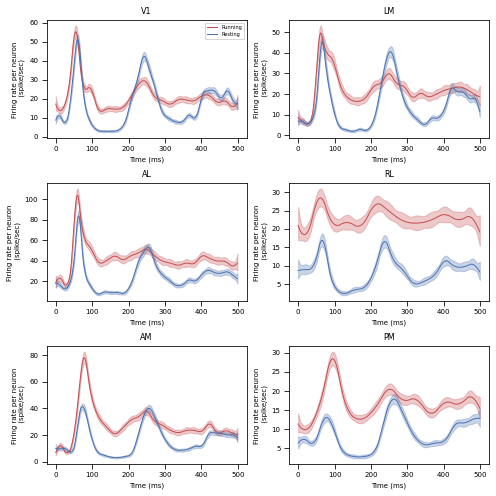

In [82]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.9,6.9))

transfer_ij = {4:0, 5:1, 0:2, 1:3, 2:4, 3:5}
num_basis_baseline1 = [25,25,25,25-10,25,25-10]
num_basis_baseline2 = [30,30,30,30-10,30,30-10]
probe_list = V1.selected_probes

for ii, target_probe in enumerate(probe_list):
    i = transfer_ij[ii]
    plt.subplot(3, 2, ii+1)
    
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline1[ii], add_constant_basis=False)
    model.fit(probe_list[i], verbose=False, penalty=1e0)
    x = model.dataset.time_line*1e3
    y, ci = model.get_filter_output(ci=True, intermediate=False)[0]
    color = 'r'
    label = 'Running'
    plt.plot(x, np.exp(y.squeeze())*1e3/mean_num_neuron[i],label=label, color=color)
    plt.fill_between(x, np.exp(y-2*ci)*1e3/mean_num_neuron[i], np.exp(y+2*ci)*1e3/mean_num_neuron[i], 
                     color=color, alpha=.3)
#     plt.plot(x,1e3*utils.kernel_smoothing(model.output.mean(axis=1)[:, np.newaxis], std=15)/num_neuron[i],
#              label=label, color=color, linewidth=3)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline2[ii], add_constant_basis=False)
    model.fit(probe_list[i], verbose=False, penalty=1)
    x = model.dataset.time_line*1e3
    y, ci = model.get_filter_output(ci=True, intermediate=False)[0]
    color = 'b'
    label = 'Resting'
    plt.plot(x, np.exp(y.squeeze())*1e3/mean_num_neuron[i],label=label, color=color)
    plt.fill_between(x, np.exp(y-2*ci)*1e3/mean_num_neuron[i], np.exp(y+2*ci)*1e3/mean_num_neuron[i],
                     color=color, alpha=.3)
#     plt.plot(x,1e3*utils.kernel_smoothing(model.output.mean(axis=1)[:, np.newaxis], std=15)/num_neuron[i],
#              label=label, color=color, linewidth=3)
    plt.xlabel('Time (ms)')
    plt.ylabel('Firing rate per neuron \n (spike/sec)')

    if ii==0:
        plt.legend()
    plt.title(utils.PROBE_CORRESPONDING[probe_list[i]])
    plt.tight_layout()
    
plt.savefig('Figures/Mean_FR.svg', format='svg', dpi=300)

## Illustrate coupling filter C

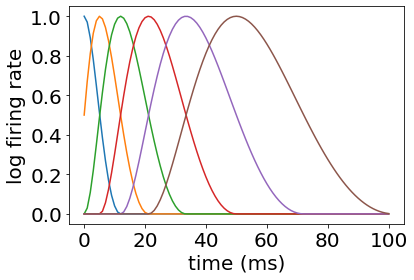

In [42]:
sns.reset_orig()
template_basis = GLM.make_pillow_basis(num=6, nonlinear=0.3, peaks_max=50, verbose=True)

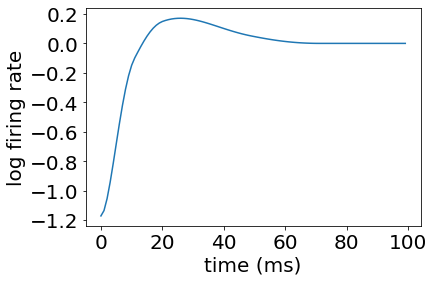

In [58]:
f = np.sum(template_basis*np.array([-1,-0.3,0.0,0.1,0.1,0])[np.newaxis, :], axis=1)

fontsize = 20
plt.figure()
plt.plot(f[1:], '-')
plt.ylabel('log firing rate',fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize) 
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()